# Transformer 自注意力和自回归机制 Q K V 计算

In [1]:
import numpy as np
from math import sqrt

def softmax(x):
    """对最后一个维度做 softmax，支持 1D 和 2D 输入。"""
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

# 缩放因子 sqrt(d_k): 点积随维度增大而增长，除以 sqrt(d_k) 可防止 softmax 进入饱和区
def scaled_dot_product_attention(Q, K, V):
    d_k = K.shape[-1]
    scores = np.dot(Q, K.T) / sqrt(d_k)
    weights = softmax(scores)
    return np.dot(weights, V)


In [2]:
# 4 tokens Let's to go <eos>
# 4 chinese tokens 我 出发 去 <eos>

input_lets = np.array([1.87, 1.09])
input_go = np.array([-1.68, 0.67])

output_chufa = np.array([-0.86, 2.37])
output_eos = np.array([2.7, -0.34])


W_q_encoder = np.array([[ 1.1, -2.8], 
                        [ 0.6,  2.4]])
W_k_encoder = np.array([[-1.7, -1.4],
                        [ 0.5,  0.9]])
W_v_encoder = np.array([[ 1.5, -0.3],
                        [-1.0, -0.2]])

# Train encoder 
q_1_encoder = np.dot(W_q_encoder, input_lets)
q_2_encoder = np.dot(W_q_encoder, input_go)
k_1_encoder = np.dot(W_k_encoder, input_lets)
k_2_encoder = np.dot(W_k_encoder, input_go)
v_1_encoder = np.dot(W_v_encoder, input_lets)
v_2_encoder = np.dot(W_v_encoder, input_go)

In [3]:
print(q_1_encoder)
print(q_2_encoder)
print(k_1_encoder)
print(k_2_encoder)
print(v_1_encoder)
print(v_2_encoder)

[-0.995  3.738]
[-3.724  0.6  ]
[-4.705  1.916]
[ 1.918 -0.237]
[ 2.478 -2.088]
[-2.721  1.546]


In [4]:
d_k = k_1_encoder.shape[0]
qk_encoder_1 = np.array([np.dot(q_1_encoder, k_1_encoder.T), np.dot(q_1_encoder, k_2_encoder.T)]) / sqrt(d_k)
print(qk_encoder_1)


[ 8.37460714 -1.97587979]


In [5]:
softmax_qk_encoder_1 = softmax(qk_encoder_1)
print(softmax_qk_encoder_1)
output_encoder_1 = np.dot(softmax_qk_encoder_1, np.array([v_1_encoder, v_2_encoder]))
print(output_encoder_1)

[9.99968024e-01 3.19761927e-05]
[ 2.47783376 -2.0878838 ]


In [6]:
qk_encoder_2 = np.array([np.dot(q_2_encoder, k_1_encoder.T), np.dot(q_2_encoder, k_2_encoder.T)]) / sqrt(d_k)
print(qk_encoder_2)


[13.20240485 -5.15115411]


In [7]:
softmax_qk_encoder_2 = softmax(qk_encoder_2)
print(softmax_qk_encoder_2)
output_encoder_2 = np.dot(softmax_qk_encoder_2, np.array([v_1_encoder, v_2_encoder]))
print(output_encoder_2)

[9.99999989e-01 1.06942570e-08]
[ 2.47799994 -2.08799996]


## Causal Mask (Autoregressive Mask) 因果掩码

在自回归生成任务（如 Decoder）中，模型只能看到当前位置及之前的 token，不能"偷看"未来的 token。因此引入**因果掩码（Causal Mask）**，它是一个下三角矩阵：

$$M_{ij} = \begin{cases} 0 & i \ge j \\ -\infty & i < j \end{cases}$$

将 $M$ 加到 attention score 上后，未来位置的权重经过 softmax 会变为 0，从而实现自回归约束。

In [8]:
import numpy as np

# 序列长度为 5 的因果掩码示例
seq_len = 5
causal_mask = np.triu(np.ones((seq_len, seq_len)), k=1) * (-1e9)
print("Causal mask (0 = allowed, -1e9 = masked):")
print(causal_mask)

# 演示：未加掩码前 score 可以注意力到未来位置
scores = np.random.randn(seq_len, seq_len)
print("\nOriginal scores:\n", scores)
masked_scores = scores + causal_mask
print("\nMasked scores:\n", masked_scores)

# 经过 softmax 后，未来位置权重为 0
e_x = np.exp(masked_scores - np.max(masked_scores, axis=-1, keepdims=True))
weights = e_x / e_x.sum(axis=-1, keepdims=True)
print("\nAttention weights after causal mask (future positions are 0):\n", np.round(weights, 4))


Causal mask (0 = allowed, -1e9 = masked):
[[-0.e+00 -1.e+09 -1.e+09 -1.e+09 -1.e+09]
 [-0.e+00 -0.e+00 -1.e+09 -1.e+09 -1.e+09]
 [-0.e+00 -0.e+00 -0.e+00 -1.e+09 -1.e+09]
 [-0.e+00 -0.e+00 -0.e+00 -0.e+00 -1.e+09]
 [-0.e+00 -0.e+00 -0.e+00 -0.e+00 -0.e+00]]

Original scores:
 [[-0.38919289  0.20659052 -1.75695901 -0.551586    0.7559257 ]
 [ 0.86921728 -0.09087754  0.57038075  0.57716195  1.02631309]
 [ 0.44671921 -1.87105608  0.5148018  -0.78053525  0.36811031]
 [-0.06661807  1.29225186 -0.72964772 -0.38290826  0.65592753]
 [-0.99818294  1.48429799 -2.05758396  0.41919125  0.66335587]]

Masked scores:
 [[-3.89192887e-01 -1.00000000e+09 -1.00000000e+09 -1.00000000e+09
  -9.99999999e+08]
 [ 8.69217276e-01 -9.08775447e-02 -9.99999999e+08 -9.99999999e+08
  -9.99999999e+08]
 [ 4.46719214e-01 -1.87105608e+00  5.14801798e-01 -1.00000000e+09
  -1.00000000e+09]
 [-6.66180733e-02  1.29225186e+00 -7.29647715e-01 -3.82908259e-01
  -9.99999999e+08]
 [-9.98182939e-01  1.48429799e+00 -2.05758396e+00 

In [9]:
resi_encoder_1 = output_encoder_1 + input_lets
resi_encoder_2 = output_encoder_2 + input_go
print(resi_encoder_1)
print(resi_encoder_2)


[ 4.34783376 -0.9978838 ]
[ 0.79799994 -1.41799996]


In [10]:
W_q_decoder = np.array([[ 0.4, -0.3],
                        [ 0.4,  0.1]])
W_k_decoder = np.array([[ 0.4, -0.4],
                        [-0.7,  0.3]])
W_v_decoder = np.array([[-1.1, -0.4],
                        [-0.7,  1.3]])

# Train decoder
q_eos_decoder = np.dot(W_q_decoder, output_eos)
k_eos_decoder = np.dot(W_k_decoder, output_eos)
v_eos_decoder = np.dot(W_v_decoder, output_eos)
print(q_eos_decoder)
print(k_eos_decoder)
print(v_eos_decoder)


[1.182 1.046]
[ 1.216 -1.992]
[-2.834 -2.332]


In [11]:
d_k_dec = k_eos_decoder.shape[0]
softmax_q_eos_decoder = softmax(np.array([np.dot(q_eos_decoder, k_eos_decoder.T)]) / sqrt(d_k_dec))
print(softmax_q_eos_decoder)
output_decoder_1_eos = softmax_q_eos_decoder * v_eos_decoder
print(output_decoder_1_eos)

resi_decoder_1_eos = output_decoder_1_eos + output_eos
print(resi_decoder_1_eos)


[1.]
[-2.834 -2.332]
[-0.134 -2.672]


In [12]:
W_q_decoder_2 = np.array([[ 1.5,  0.3],
                          [-0.3,  1.0]])
W_k_encoder_2 = np.array([[-1.1, -0.3],
                          [ 0.3, -0.8]])
W_v_encoder_2 = np.array([[ 1.1, -1.2],
                          [ 0.6, -0.5]])

q_eos_decoder_2 = np.dot(W_q_decoder_2, resi_decoder_1_eos)
print(q_eos_decoder_2)


k_1_encoder_2 = np.dot(W_k_encoder_2, resi_encoder_1)
k_2_encoder_2 = np.dot(W_k_encoder_2, resi_encoder_2)
print(k_1_encoder_2)
print(k_2_encoder_2)


d_k_enc_2 = k_1_encoder_2.shape[0]
softmax_q_eos_decoder_2 = softmax(np.array([np.dot(q_eos_decoder_2, k_1_encoder_2.T), np.dot(q_eos_decoder_2, k_2_encoder_2.T)]) / sqrt(d_k_enc_2))
print(softmax_q_eos_decoder_2)


v_1_encoder_2 = np.dot(W_v_encoder_2, resi_encoder_1)
v_2_encoder_2 = np.dot(W_v_encoder_2, resi_encoder_2)
print(v_1_encoder_2)
print(v_2_encoder_2)

output_decoder_2_eos = np.dot(softmax_q_eos_decoder_2, np.array([v_1_encoder_2, v_2_encoder_2]))
print(output_decoder_2_eos)

resi_decoder_2_eos = output_decoder_2_eos + resi_decoder_1_eos
print(resi_decoder_2_eos)

word_array_output = np.array([[-0.6, -2.0],
                              [ 0.8, -0.9],
                              [-0.1, -1.1],
                              [-1.0,  1.6]])
bias_output = np.array([-0.6, 1.4, -2.5, 0.5]).T
first_output = softmax(np.dot(word_array_output, resi_decoder_2_eos) + bias_output)
print(first_output)


[-1.0026 -2.6318]
[-4.48325199  2.10265717]
[-0.45239995  1.37379995]
[0.81776481 0.18223519]
[5.98007769 3.10764215]
[2.57939989 1.18779995]
[5.36035453 2.75777935]
[5.22635453 0.08577935]
[8.17735231e-05 9.99696623e-01 1.80247731e-04 4.13559931e-05]


**可视化：自注意力权重矩阵**

下面通过热力图直观展示前面手算得到的两个 query token 对两个 key token 的注意力权重。

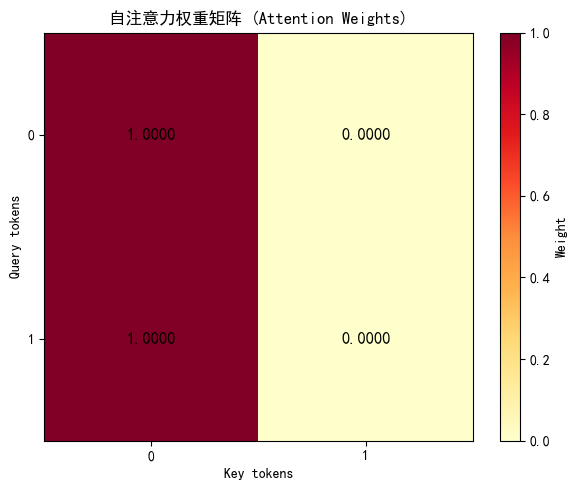

In [13]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 构造完整的注意力权重矩阵（2 个 query token × 2 个 key token）
attention_weights = np.array([softmax_qk_encoder_1, softmax_qk_encoder_2])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attention_weights, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

# 在每个格子里写上权重数值
for i in range(attention_weights.shape[0]):
    for j in range(attention_weights.shape[1]):
        ax.text(j, i, f'{attention_weights[i, j]:.4f}',
                ha='center', va='center', color='black', fontsize=12)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlabel('Key tokens')
ax.set_ylabel('Query tokens')
ax.set_title('自注意力权重矩阵 (Attention Weights)')
fig.colorbar(im, ax=ax, label='Weight')
plt.tight_layout()
plt.show()


**可视化：因果掩码**

在自回归 Decoder 中，因果掩码是一个下三角矩阵，保证 query 只能关注当前及之前的位置，不能"偷看"未来 token。

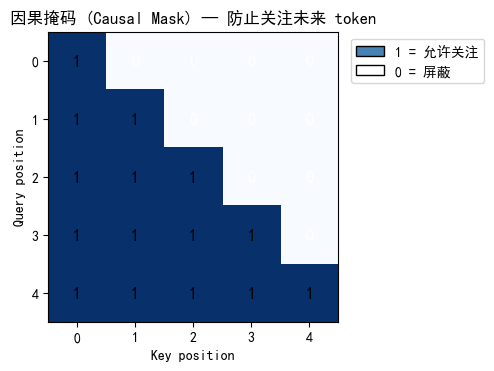

In [14]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 构造一个二值化的下三角掩码便于展示
causal_mask_viz = np.tril(np.ones((5, 5)))

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(causal_mask_viz, cmap='Blues', vmin=0, vmax=1)

# 在每个格子里标注 1 或 0
for i in range(5):
    for j in range(5):
        val = causal_mask_viz[i, j]
        ax.text(j, i, f'{int(val)}',
                ha='center', va='center',
                color='white' if val == 0 else 'black', fontsize=12)

ax.set_xticks(np.arange(5))
ax.set_yticks(np.arange(5))
ax.set_xlabel('Key position')
ax.set_ylabel('Query position')
ax.set_title('因果掩码 (Causal Mask) — 防止关注未来 token')

legend_elements = [
    Patch(facecolor='steelblue', edgecolor='k', label='1 = 允许关注'),
    Patch(facecolor='white', edgecolor='k', label='0 = 屏蔽')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()
